# cer-transfer demo

Reconstruct ion temperature and rotation profiles from CER spectrograms with a
pretrained model, and compare them with the conventional fits. Runs on CPU in
well under a minute.

Needs the repository (this notebook lives in `notebooks/`) with its environment
(`pixi install`; kernel "cer-transfer (pixi)"). Files: a checkpoint and one
discharge, either local (`cer_ckpts/`, `CER_DATA_ROOT`) or, once published,
downloaded from the release in the next cell.

In [1]:
import os, sys, urllib.request
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from cer_transfer.configs import data_path

RELEASE = None   # e.g. "https://github.com/<org>/<repo>/releases/download/v1.0" once published
DEMO = ROOT / "demo"

if RELEASE:
    DEMO.mkdir(exist_ok=True)
    for name in ("nstx_ft_inference.pt", "chers_137711.joblib"):
        if not (DEMO / name).exists():
            print("downloading", name)
            urllib.request.urlretrieve(f"{RELEASE}/{name}", DEMO / name)
    CKPT, SHOT = DEMO / "nstx_ft_inference.pt", DEMO / "chers_137711.joblib"
else:
    # local files: the trained checkpoint and discharge 137711 from the validation list
    CKPT = ROOT / "cer_ckpts" / "nstx_ft.pt"
    entry = next(ln for ln in (ROOT / "splits" / "nstx_val.txt").read_text().splitlines() if "137711" in ln)
    SHOT = data_path(entry)      # resolved against CER_DATA_ROOT
print("checkpoint:", CKPT, "\ndischarge: ", SHOT)
assert CKPT.exists() and SHOT.exists(), "set RELEASE, or CER_DATA_ROOT and cer_ckpts/"


checkpoint: /scratch/gpfs/EKOLEMEN/ps9551/cer_transfer_learning/cer_ckpts/nstx_ft.pt 
discharge:  /scratch/gpfs/NSTX-U/chers_nstx_labeled/chers_137711.joblib


## Load the model and run it on one discharge

In [2]:
from cer_transfer.inference import load_model, predict_file

m = load_model(CKPT)
print(f"machine {m.machine.name}: {m.machine.n_chords} chords, targets {list(m.machine.targets)}; "
      f"validation score {m.best_score:.3f}")

r = predict_file(m, SHOT)
C, T, _ = r.pred.shape
print(f"{C} chords x {T} frames; conventional fits on "
      f"{int((~__import__('numpy').isnan(r.y[..., 0])).sum())} of {C * T} chord-frames")

machine nstx: 51 chords, targets ['ti', 'vtor']; validation score 0.771
indexed 1 files in 0.0s (6.7 ms/file effective)
51 chords x 279 frames; conventional fits on 3616 of 14229 chord-frames


`r.pred[chord, frame, k]` is the reconstruction (k = 0: T_i in eV, k = 1: v_tor in km/s),
`r.pred_sigma` its uncertainty, `r.y` / `r.sigma` the conventional fits where they exist.
NSTX CHERS records at 200 Hz; the recording starts 235 ms before the experimental clock zero.

## Time traces of two chords

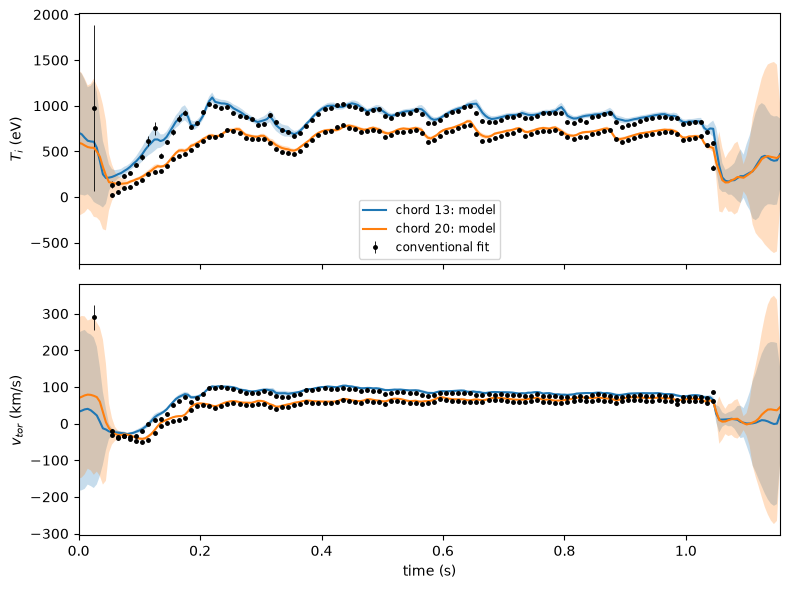

In [3]:
import numpy as np
import matplotlib.pyplot as plt

t = np.arange(T) / 200.0 - 0.235
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for k, (ax, lab) in enumerate(zip(axes, ("$T_i$ (eV)", "$v_{tor}$ (km/s)"))):
    for i, c in enumerate((13, 20)):
        ax.fill_between(t, r.pred[c, :, k] - r.pred_sigma[c, :, k], r.pred[c, :, k] + r.pred_sigma[c, :, k],
                        color=f"C{i}", alpha=0.25, lw=0)
        ax.plot(t, r.pred[c, :, k], color=f"C{i}", lw=1.5, label=f"chord {c}: model")
        ok = np.isfinite(r.y[c, :, k])
        ax.errorbar(t[ok], r.y[c, ok, k], yerr=r.sigma[c, ok, k], fmt="o", ms=2.5, lw=0.6, color="k",
                    label="conventional fit" if i == 0 else None)
    ax.set_ylabel(lab); ax.set_xlim(0, t[-1])
axes[0].legend(fontsize="small"); axes[1].set_xlabel("time (s)")
plt.tight_layout()

## Profiles at one time, including chords without a conventional fit

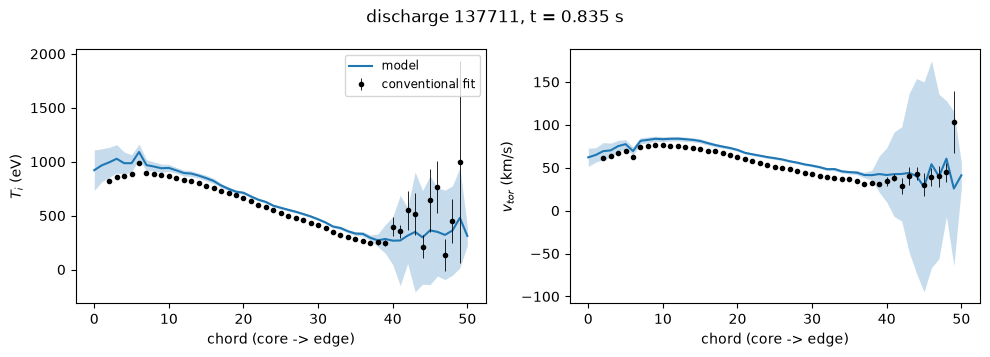

In [4]:
f = int(np.argmax(np.isfinite(r.y[:, :, 0]).sum(axis=0)))        # frame with the most fits
x = np.arange(C)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for k, (ax, lab) in enumerate(zip(axes, ("$T_i$ (eV)", "$v_{tor}$ (km/s)"))):
    ax.fill_between(x, r.pred[:, f, k] - r.pred_sigma[:, f, k], r.pred[:, f, k] + r.pred_sigma[:, f, k],
                    color="C0", alpha=0.25, lw=0)
    ax.plot(x, r.pred[:, f, k], color="C0", lw=1.5, label="model")
    ok = np.isfinite(r.y[:, f, k])
    ax.errorbar(x[ok], r.y[ok, f, k], yerr=r.sigma[ok, f, k], fmt="o", ms=3, lw=0.6, color="k",
                label="conventional fit")
    ax.set_xlabel("chord (core -> edge)"); ax.set_ylabel(lab)
axes[0].legend(fontsize="small"); fig.suptitle(f"discharge 137711, t = {t[f]:.3f} s")
plt.tight_layout()

The model returns values for every chord and frame; the conventional analysis
only where a Gaussian fit converged. For the background-array model and the
beam-off examples see `scripts/make_figs.sh` and `cer_transfer/figures/`.